In [3]:
import torch
if torch.cuda.is_available():
    print("GPU is available")
else:
    print("No GPU available, running on CPU")


GPU is available


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [5]:
import pandas as pd 
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, dataloader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [6]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [7]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


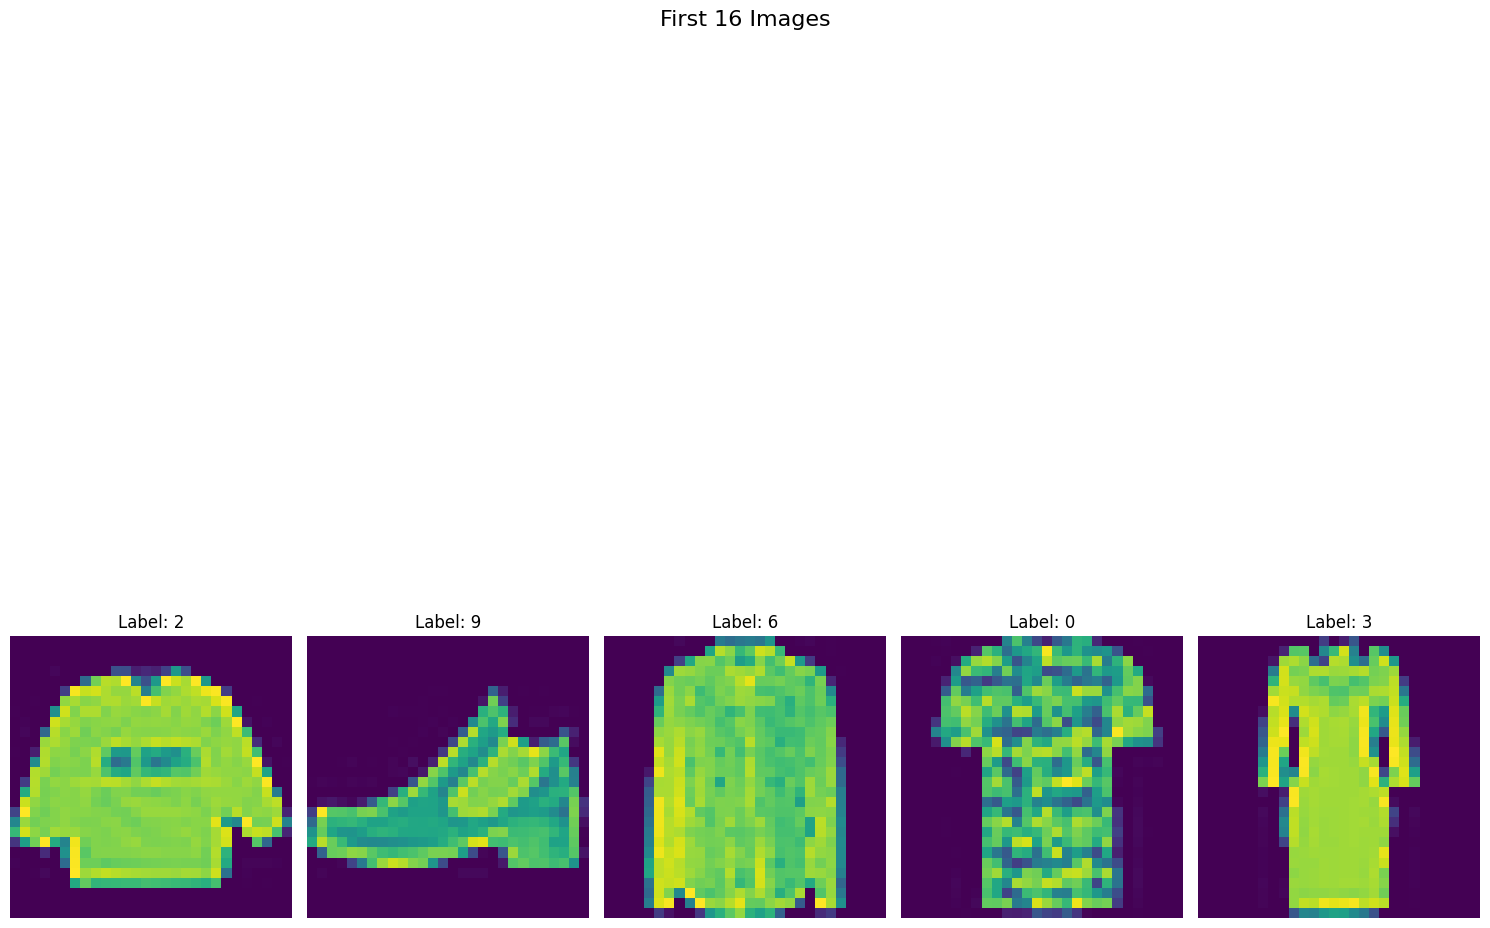

In [8]:
fig , axes = plt.subplots(1,5,figsize=(15,15))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [9]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [13]:
#creating a custom dataset class
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features=torch.tensor(features, dtype=torch.float32)
    self.labels=torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [14]:
train_dataset=CustomDataset(X_train, y_train)
test_dataset=CustomDataset(X_test, y_test)

In [15]:
# create train and test loader
train_loader = dataloader.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = dataloader.DataLoader(test_dataset, batch_size=32, shuffle=False)

In [16]:
class myNN(nn.Module):
  def __init__(self , num_features):
    super().__init__()
    self.model=nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)                     

    )
  def forward(self, x):
    return self.model(x)


In [17]:
epochs=100
learning_rate=0.1

In [18]:
model=myNN(X_train.shape[1])
model.to(device)

myNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [19]:
criterion= nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=learning_rate)

In [20]:
for epoch in range(epochs):
  total_epoch_loss=0
  for batch_features, batch_labels in train_loader:
      
      
    batch_features, batch_labels= batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)
    loss=criterion(outputs, batch_labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #loss after every epoch
    total_epoch_loss+=loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 0.6351298266450565
Epoch: 2 , Loss: 0.4297934276709954
Epoch: 3 , Loss: 0.38633426661789416
Epoch: 4 , Loss: 0.35881559780736766
Epoch: 5 , Loss: 0.3375592668503523
Epoch: 6 , Loss: 0.32237412882844607
Epoch: 7 , Loss: 0.3083759152467052
Epoch: 8 , Loss: 0.29549292523165543
Epoch: 9 , Loss: 0.28609639733284714
Epoch: 10 , Loss: 0.2748781508853038
Epoch: 11 , Loss: 0.2675727439771096
Epoch: 12 , Loss: 0.25692630486935375
Epoch: 13 , Loss: 0.24977530097961426
Epoch: 14 , Loss: 0.24362681192283828
Epoch: 15 , Loss: 0.2375376468518128
Epoch: 16 , Loss: 0.2320030338068803
Epoch: 17 , Loss: 0.22566000659515462
Epoch: 18 , Loss: 0.22124118285253644
Epoch: 19 , Loss: 0.2166428222510343
Epoch: 20 , Loss: 0.2092639690078795
Epoch: 21 , Loss: 0.20460349281008045
Epoch: 22 , Loss: 0.20043948280780266
Epoch: 23 , Loss: 0.1956038682150344
Epoch: 24 , Loss: 0.19381978604445854
Epoch: 25 , Loss: 0.187977629793187
Epoch: 26 , Loss: 0.18313644774568577
Epoch: 27 , Loss: 0.18247325640544

In [22]:
model.eval()

myNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [23]:
#evalcode
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:
    batch_features, batch_labels= batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)
print(total)


0.8785
12000
